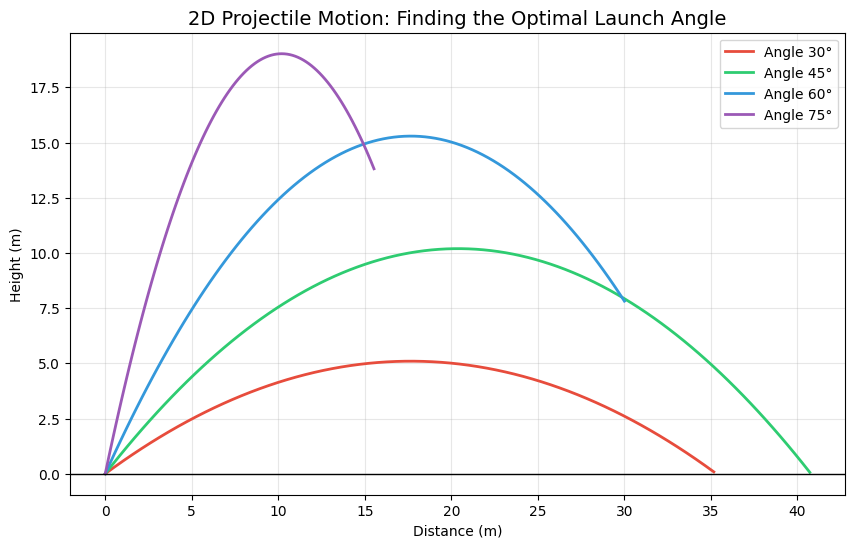

✅ 3D Asset saved: ../../../assets/61_projectile_3d.png


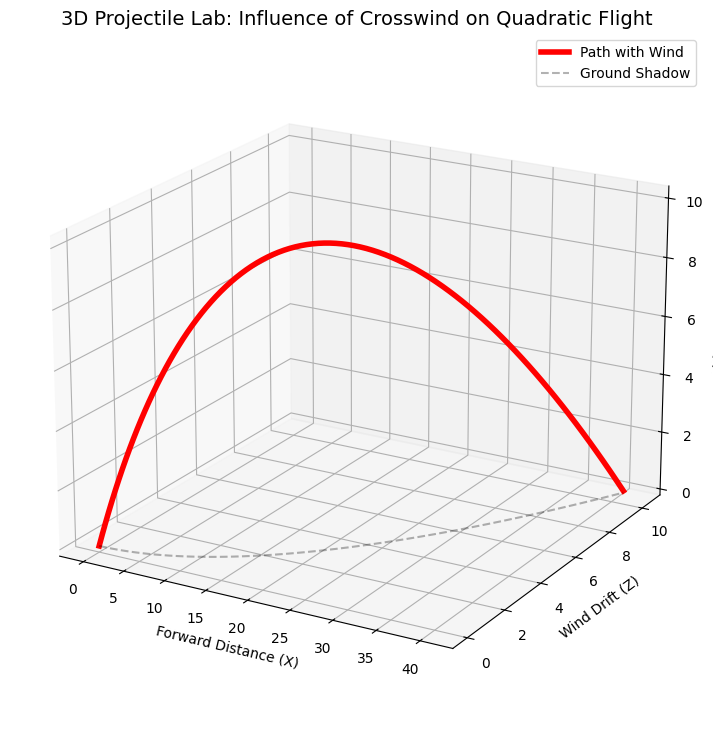

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def run_projectile_master():
    # --- PROFESSIONAL PATH SETUP ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Constants
    g = 9.81  # Gravity
    v0 = 20   # Initial velocity (m/s)
    t_flight = np.linspace(0, 3, 100)

    # --- 📸 ASSET 1: 2D MULTI-ANGLE COMPARISON (61_projectile_2d.png) ---
    plt.figure(figsize=(10, 6))
    angles = [30, 45, 60, 75]
    colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

    for angle, col in zip(angles, colors):
        rad = np.radians(angle)
        x = v0 * np.cos(rad) * t_flight
        y = v0 * np.sin(rad) * t_flight - 0.5 * g * t_flight**2
        
        # Only plot points above ground
        x, y = x[y >= 0], y[y >= 0]
        plt.plot(x, y, label=f'Angle {angle}°', lw=2, color=col)

    plt.title("2D Projectile Motion: Finding the Optimal Launch Angle", fontsize=14)
    plt.xlabel("Distance (m)"); plt.ylabel("Height (m)")
    plt.axhline(0, color='black', lw=1); plt.grid(alpha=0.3)
    plt.legend()
    
    plt.savefig(os.path.join(asset_path, '61_projectile_2d.png'), dpi=300)
    plt.show()

    # --- 📸 ASSET 2: 3D TRAJECTORY WITH CROSSWIND (61_projectile_3d.png) ---
    fig = plt.figure(figsize=(12, 9))
    ax3d = fig.add_subplot(111, projection='3d')
    
    # Launch at 45 degrees
    rad = np.radians(45)
    wind_speed = 2.5 # m/s pushing in Z direction
    
    # X = Horizontal forward, Y = Vertical, Z = Horizontal side (wind)
    X_fwd = v0 * np.cos(rad) * t_flight
    Y_alt = v0 * np.sin(rad) * t_flight - 0.5 * g * t_flight**2
    Z_side = 0.5 * wind_speed * t_flight**2 # Wind acceleration effect
    
    # Filter ground
    mask = Y_alt >= 0
    ax3d.plot(X_fwd[mask], Z_side[mask], Y_alt[mask], 'r-', lw=4, label='Path with Wind')
    
    # Draw shadows on the ground for depth
    ax3d.plot(X_fwd[mask], Z_side[mask], 0, 'k--', alpha=0.3, label='Ground Shadow')

    ax3d.set_title("3D Projectile Lab: Influence of Crosswind on Quadratic Flight", fontsize=14)
    ax3d.set_xlabel("Forward Distance (X)"); ax3d.set_ylabel("Wind Drift (Z)"); ax3d.set_zlabel("Altitude (Y)")
    ax3d.legend()
    ax3d.view_init(elev=20, azim=-60)

    plt.savefig(os.path.join(asset_path, '61_projectile_3d.png'), dpi=300)
    print(f"✅ 3D Asset saved: {asset_path}/61_projectile_3d.png")
    plt.show()

if __name__ == "__main__":
    run_projectile_master()